In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Linear SVM",
        "Logistic Regression"
    ],
    
    "Accuracy (%)": [
        87.96,
        87.58,
        85.52,
        82.19,
        82.33
    ],
    
    "Precision (%)": [
        96.17,
        96.04,
        94.95,
        89.81,
        90.02
    ],
    
    "Recall (%)": [
        78.21,
        77.50,
        73.97,
        71.22,
        71.36
    ],
    
    "F1 (%)": [
        86.27,
        85.78,
        83.16,
        79.44,
        79.61
    ],
    
    "Zero-Day Detection (%)": [
        36.64,
        44.11,
        40.77,
        37.01,
        40.91
    ],
    
    "FPR (%)": [
        2.91,
        2.99,
        3.68,
        7.56,
        7.40
    ]
})

final_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 (%),Zero-Day Detection (%),FPR (%)
0,Decision Tree,87.96,96.17,78.21,86.27,36.64,2.91
1,Random Forest,87.58,96.04,77.50,85.78,44.11,2.99
2,KNN,85.52,94.95,73.97,83.16,40.77,3.68
3,Linear SVM,82.19,89.81,71.22,79.44,37.01,7.56
4,Logistic Regression,82.33,90.02,71.36,79.61,40.91,7.40


In [3]:
final_results.to_csv(
    "../results/final_tuned_model_results.csv",
    index=False
)

print("Final results table saved.")

Final results table saved.


In [4]:
f1_ranking = (
    final_results[
        ["Model", "F1 (%)"]
    ]
    .sort_values(
        "F1 (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

f1_ranking

,Model,F1 (%)
0,Decision Tree,86.27
1,Random Forest,85.78
2,KNN,83.16
3,Logistic Regression,79.61
4,Linear SVM,79.44


In [5]:
zero_day_ranking = (
    final_results[
        ["Model", "Zero-Day Detection (%)"]
    ]
    .sort_values(
        "Zero-Day Detection (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

zero_day_ranking

,Model,Zero-Day Detection (%)
0,Random Forest,44.11
1,Logistic Regression,40.91
2,KNN,40.77
3,Linear SVM,37.01
4,Decision Tree,36.64


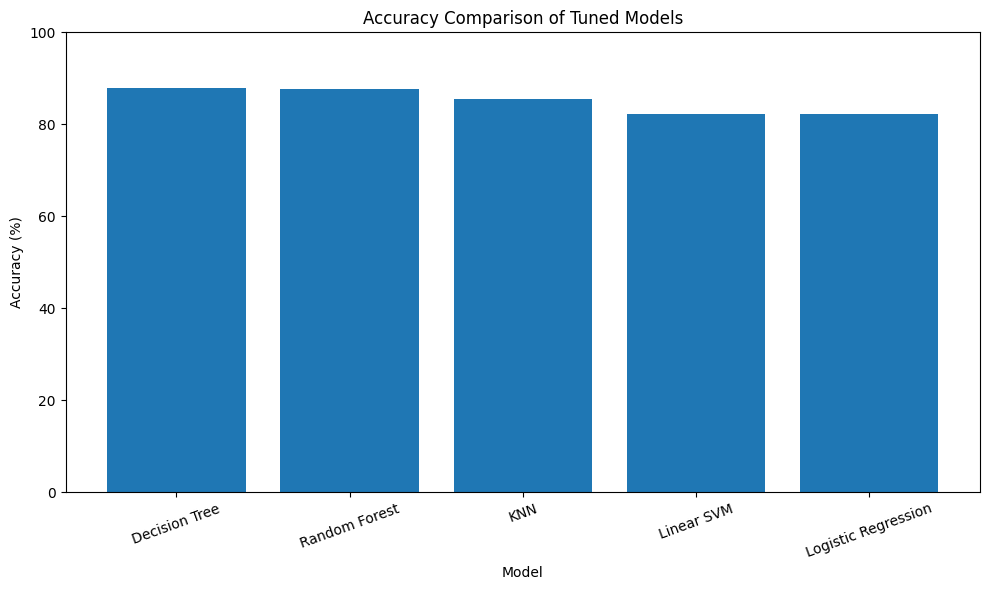

In [6]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Accuracy Comparison of Tuned Models")

plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

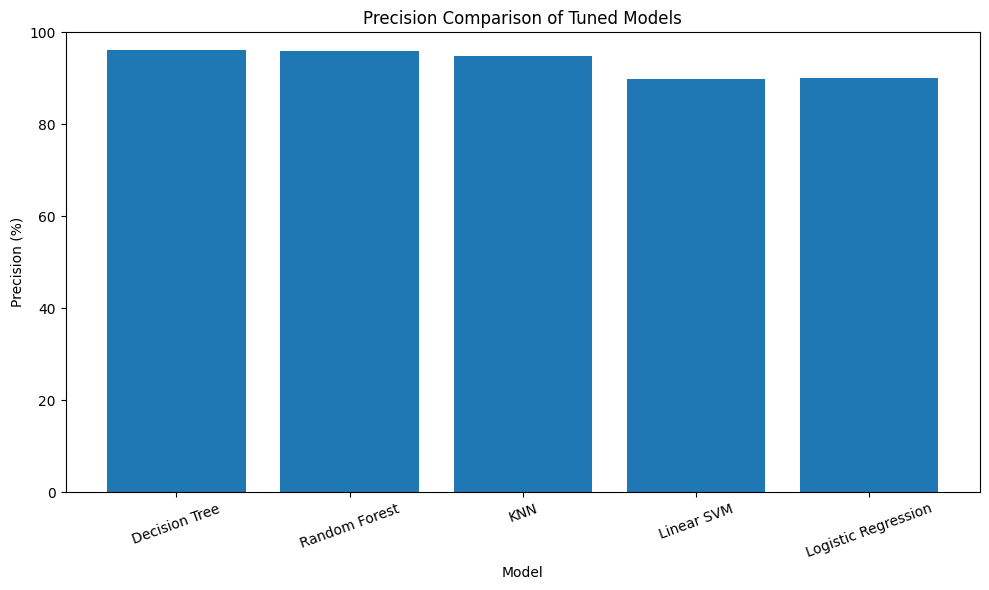

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["Precision (%)"]
)

plt.ylabel("Precision (%)")
plt.xlabel("Model")
plt.title("Precision Comparison of Tuned Models")

plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

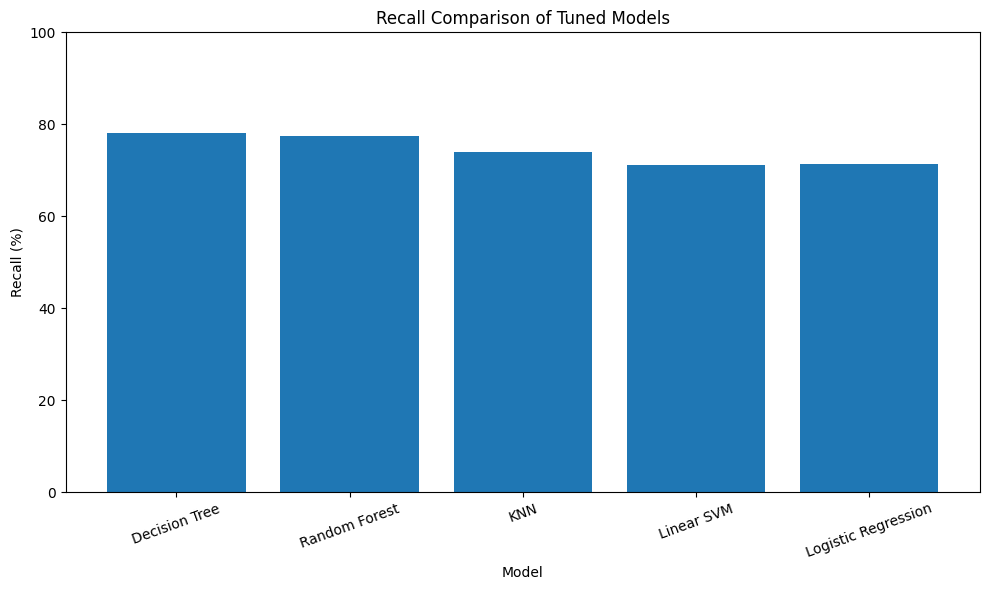

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["Recall (%)"]
)

plt.ylabel("Recall (%)")
plt.xlabel("Model")
plt.title("Recall Comparison of Tuned Models")

plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

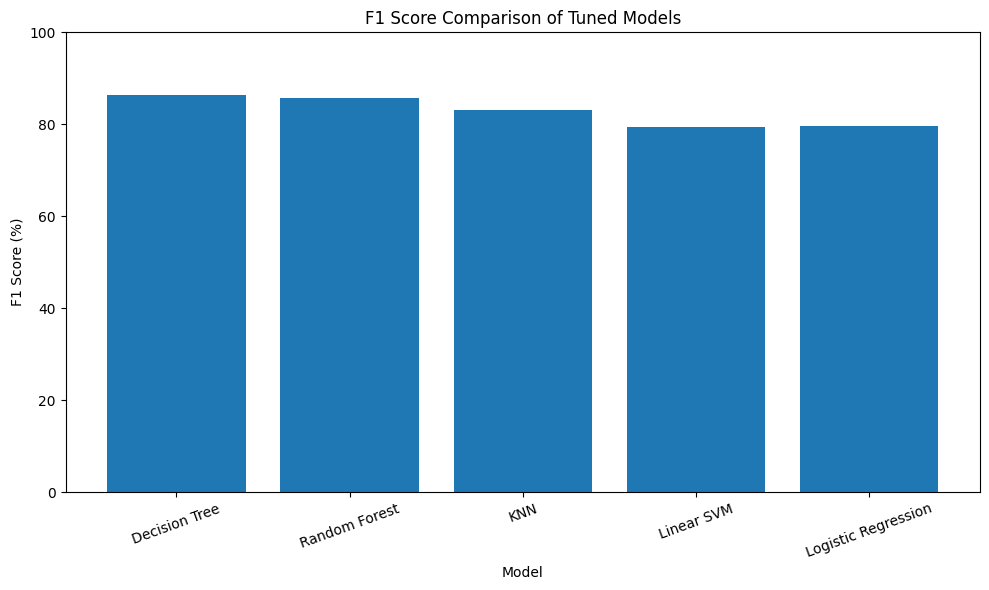

In [9]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["F1 (%)"]
)

plt.ylabel("F1 Score (%)")
plt.xlabel("Model")
plt.title("F1 Score Comparison of Tuned Models")

plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

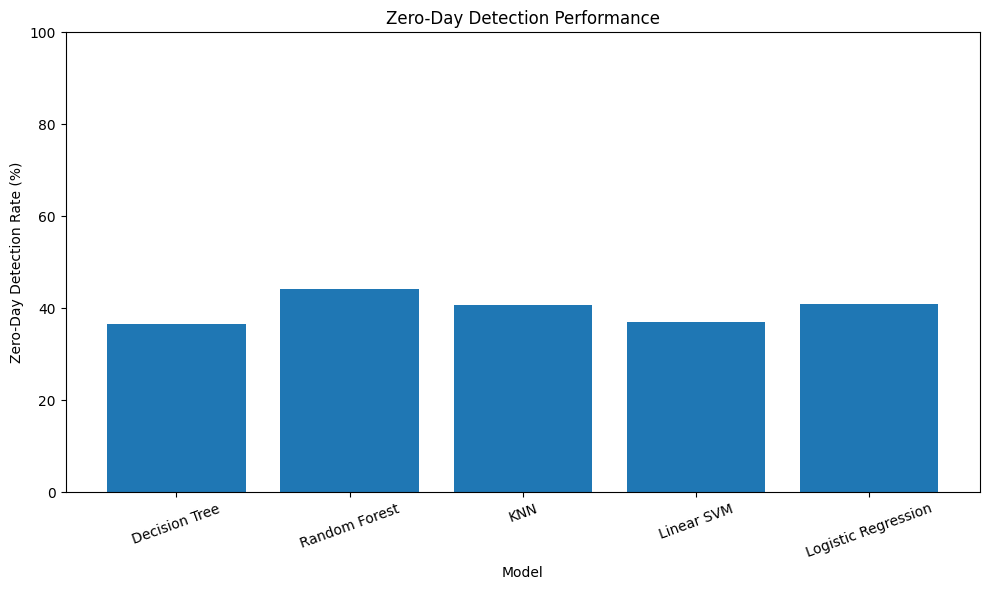

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["Zero-Day Detection (%)"]
)

plt.ylabel("Zero-Day Detection Rate (%)")
plt.xlabel("Model")
plt.title("Zero-Day Detection Performance")

plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

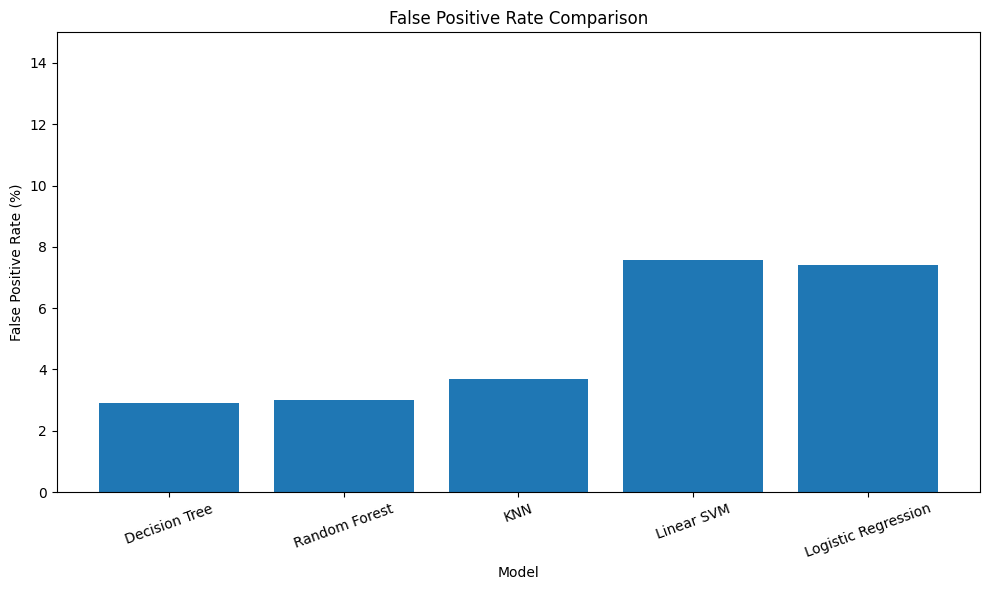

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["FPR (%)"]
)

plt.ylabel("False Positive Rate (%)")
plt.xlabel("Model")
plt.title("False Positive Rate Comparison")

plt.xticks(rotation=20)
plt.ylim(0, 15)

plt.tight_layout()
plt.show()

In [12]:
comparison_seen_zero = pd.DataFrame({
    "Model": final_results["Model"],
    "Seen F1 (%)": final_results["F1 (%)"],
    "Zero-Day Detection (%)": final_results["Zero-Day Detection (%)"]
})

comparison_seen_zero

,Model,Seen F1 (%),Zero-Day Detection (%)
0,Decision Tree,86.27,36.64
1,Random Forest,85.78,44.11
2,KNN,83.16,40.77
3,Linear SVM,79.44,37.01
4,Logistic Regression,79.61,40.91


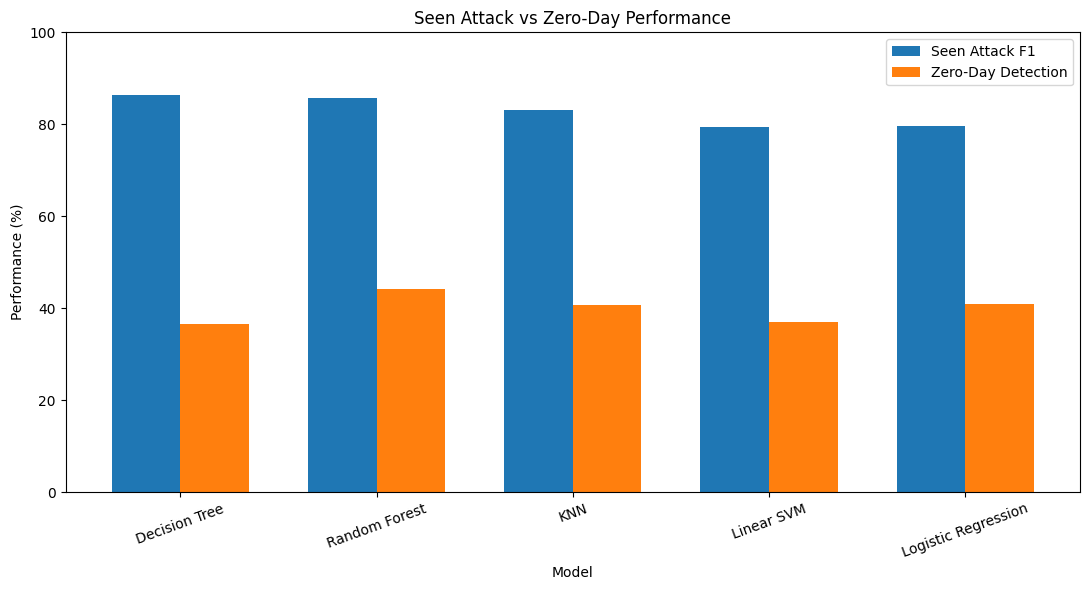

In [13]:
x = np.arange(len(comparison_seen_zero))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    comparison_seen_zero["Seen F1 (%)"],
    width,
    label="Seen Attack F1"
)

plt.bar(
    x + width / 2,
    comparison_seen_zero["Zero-Day Detection (%)"],
    width,
    label="Zero-Day Detection"
)

plt.ylabel("Performance (%)")
plt.xlabel("Model")
plt.title("Seen Attack vs Zero-Day Performance")

plt.xticks(
    x,
    comparison_seen_zero["Model"],
    rotation=20
)

plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
per_attack = pd.read_csv(
    "../results/per_attack_tuned_models.csv"
)

per_attack

,Attack Type,Samples,Decision Tree (%),Random Forest (%),KNN (%),Linear SVM (%),Logistic Regression (%)
0,apache2,737,66.62,61.47,54.82,99.19,99.05
1,httptunnel,133,12.78,60.90,14.29,1.50,1.50
2,mailbomb,293,0.68,0.00,0.00,0.00,0.00
3,mscan,996,52.51,57.83,77.21,34.24,49.20
4,named,17,17.65,29.41,35.29,5.88,5.88
5,processtable,685,2.63,30.22,1.31,0.44,0.29
6,ps,15,13.33,53.33,20.00,0.00,0.00
7,saint,319,97.18,99.37,97.49,95.30,94.98
8,sendmail,14,0.00,0.00,7.14,7.14,7.14
9,snmpgetattack,178,0.00,0.00,0.56,0.56,0.56


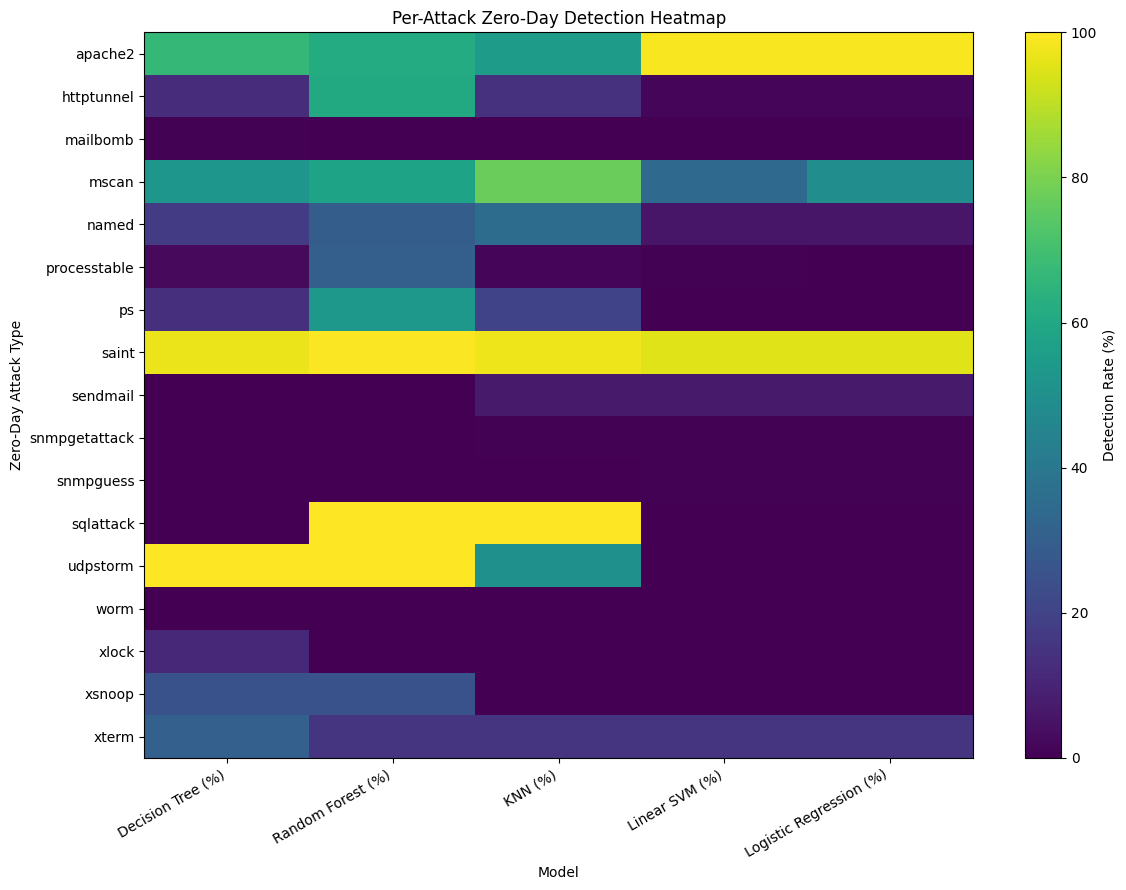

In [15]:
attack_heatmap = per_attack.set_index(
    "Attack Type"
)[
    [
        "Decision Tree (%)",
        "Random Forest (%)",
        "KNN (%)",
        "Linear SVM (%)",
        "Logistic Regression (%)"
    ]
]

plt.figure(figsize=(12, 9))

plt.imshow(
    attack_heatmap.values,
    aspect="auto"
)

plt.colorbar(
    label="Detection Rate (%)"
)

plt.xticks(
    range(len(attack_heatmap.columns)),
    attack_heatmap.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(attack_heatmap.index)),
    attack_heatmap.index
)

plt.xlabel("Model")
plt.ylabel("Zero-Day Attack Type")
plt.title("Per-Attack Zero-Day Detection Heatmap")

plt.tight_layout()
plt.show()

In [16]:
attack_columns = [
    "Decision Tree (%)",
    "Random Forest (%)",
    "KNN (%)",
    "Linear SVM (%)",
    "Logistic Regression (%)"
]

per_attack["Mean Detection (%)"] = (
    per_attack[attack_columns]
    .mean(axis=1)
)

per_attack[
    [
        "Attack Type",
        "Samples",
        "Mean Detection (%)"
    ]
].sort_values(
    "Mean Detection (%)"
)

,Attack Type,Samples,Mean Detection (%)
13,worm,2,0.000
2,mailbomb,293,0.136
10,snmpguess,331,0.300
9,snmpgetattack,178,0.336
14,xlock,9,2.222
8,sendmail,14,4.284
5,processtable,685,6.978
15,xsnoop,4,10.000
6,ps,15,17.332
1,httptunnel,133,18.194


In [17]:
hardest_attacks = (
    per_attack[
        [
            "Attack Type",
            "Samples",
            "Mean Detection (%)"
        ]
    ]
    .sort_values(
        "Mean Detection (%)",
        ascending=True
    )
)

hardest_attacks

,Attack Type,Samples,Mean Detection (%)
13,worm,2,0.000
2,mailbomb,293,0.136
10,snmpguess,331,0.300
9,snmpgetattack,178,0.336
14,xlock,9,2.222
8,sendmail,14,4.284
5,processtable,685,6.978
15,xsnoop,4,10.000
6,ps,15,17.332
1,httptunnel,133,18.194


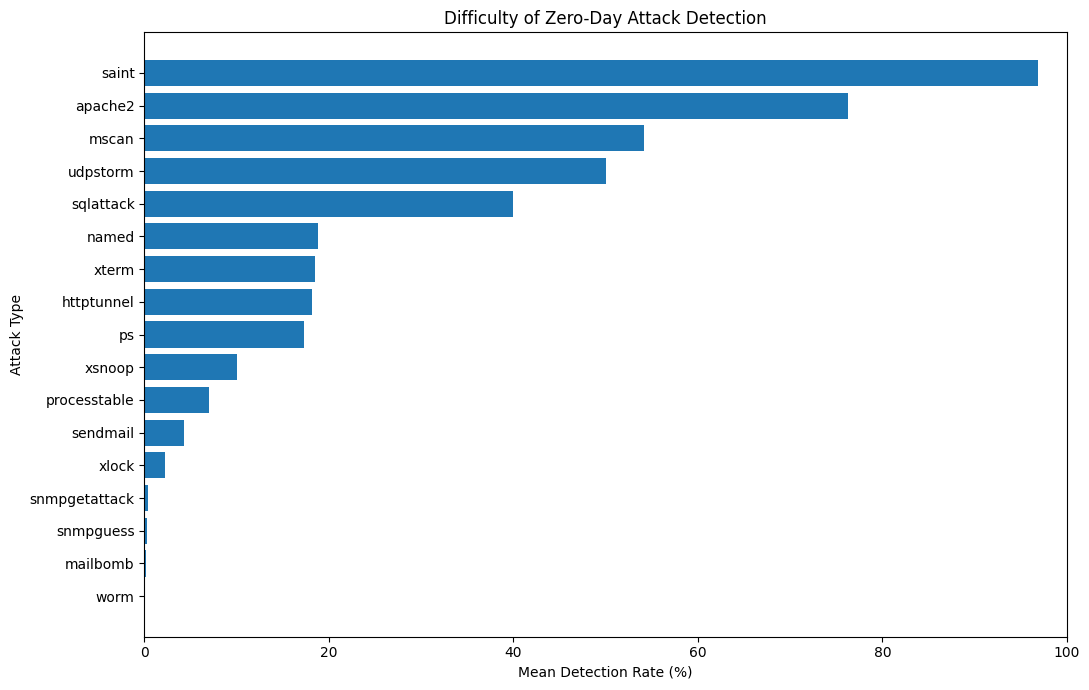

In [18]:
plt.figure(figsize=(11, 7))

plt.barh(
    hardest_attacks["Attack Type"],
    hardest_attacks["Mean Detection (%)"]
)

plt.xlabel("Mean Detection Rate (%)")
plt.ylabel("Attack Type")
plt.title("Difficulty of Zero-Day Attack Detection")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [19]:
per_attack["Best Model"] = (
    per_attack[attack_columns]
    .idxmax(axis=1)
)

best_per_attack = per_attack[
    [
        "Attack Type",
        "Samples",
        *attack_columns,
        "Best Model"
    ]
]

best_per_attack

,Attack Type,Samples,Decision Tree (%),Random Forest (%),KNN (%),Linear SVM (%),Logistic Regression (%),Best Model
0,apache2,737,66.62,61.47,54.82,99.19,99.05,Linear SVM (%)
1,httptunnel,133,12.78,60.90,14.29,1.50,1.50,Random Forest (%)
2,mailbomb,293,0.68,0.00,0.00,0.00,0.00,Decision Tree (%)
3,mscan,996,52.51,57.83,77.21,34.24,49.20,KNN (%)
4,named,17,17.65,29.41,35.29,5.88,5.88,KNN (%)
5,processtable,685,2.63,30.22,1.31,0.44,0.29,Random Forest (%)
6,ps,15,13.33,53.33,20.00,0.00,0.00,Random Forest (%)
7,saint,319,97.18,99.37,97.49,95.30,94.98,Random Forest (%)
8,sendmail,14,0.00,0.00,7.14,7.14,7.14,KNN (%)
9,snmpgetattack,178,0.00,0.00,0.56,0.56,0.56,KNN (%)


In [20]:
model_wins = (
    per_attack["Best Model"]
    .value_counts()
)

model_wins

Best Model
Decision Tree (%)    6
Random Forest (%)    5
KNN (%)              4
Linear SVM (%)       2
Name: count, dtype: int64

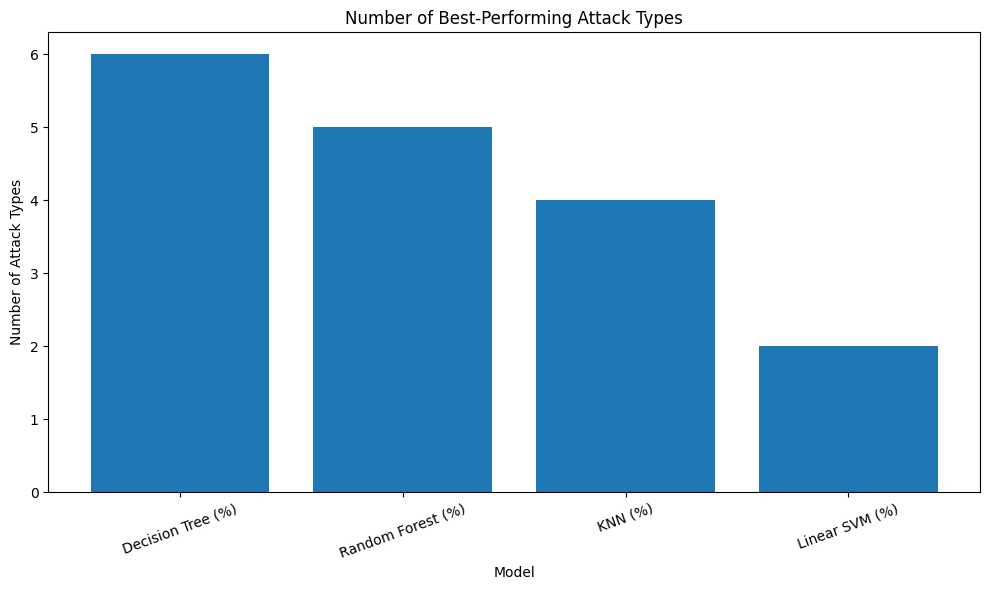

In [21]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_wins.index,
    model_wins.values
)

plt.ylabel("Number of Attack Types")
plt.xlabel("Model")
plt.title("Number of Best-Performing Attack Types")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [22]:
final_comparison = final_results.copy()

final_comparison["F1 Rank"] = (
    final_comparison["F1 (%)"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

final_comparison["Zero-Day Rank"] = (
    final_comparison["Zero-Day Detection (%)"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

final_comparison = final_comparison.sort_values(
    "F1 Rank"
)

final_comparison

,Model,Accuracy (%),Precision (%),Recall (%),F1 (%),Zero-Day Detection (%),FPR (%),F1 Rank,Zero-Day Rank
0,Decision Tree,87.96,96.17,78.21,86.27,36.64,2.91,1,5
1,Random Forest,87.58,96.04,77.50,85.78,44.11,2.99,2,1
2,KNN,85.52,94.95,73.97,83.16,40.77,3.68,3,3
4,Logistic Regression,82.33,90.02,71.36,79.61,40.91,7.40,4,2
3,Linear SVM,82.19,89.81,71.22,79.44,37.01,7.56,5,4


In [23]:
best_f1_model = final_results.loc[
    final_results["F1 (%)"].idxmax()
]

best_zero_day_model = final_results.loc[
    final_results["Zero-Day Detection (%)"].idxmax()
]

lowest_fpr_model = final_results.loc[
    final_results["FPR (%)"].idxmin()
]

print("Best F1 Model:")
print(best_f1_model["Model"])
print(best_f1_model["F1 (%)"])

print("\nBest Zero-Day Detection Model:")
print(best_zero_day_model["Model"])
print(best_zero_day_model["Zero-Day Detection (%)"])

print("\nLowest FPR Model:")
print(lowest_fpr_model["Model"])
print(lowest_fpr_model["FPR (%)"])

Best F1 Model:
Decision Tree
86.27

Best Zero-Day Detection Model:
Random Forest
44.11

Lowest FPR Model:
Decision Tree
2.91


In [24]:
final_comparison.to_csv(
    "../results/final_comparison.csv",
    index=False
)

per_attack.to_csv(
    "../results/final_per_attack_analysis.csv",
    index=False
)

model_wins.to_csv(
    "../results/model_wins_per_attack.csv"
)

hardest_attacks.to_csv(
    "../results/hardest_zero_day_attacks.csv",
    index=False
)

print("All final results saved successfully.")

All final results saved successfully.


In [25]:
print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print(
    f"\nBest overall F1 model: "
    f"{best_f1_model['Model']} "
    f"({best_f1_model['F1 (%)']:.2f}%)"
)

print(
    f"Best Zero-Day detection model: "
    f"{best_zero_day_model['Model']} "
    f"({best_zero_day_model['Zero-Day Detection (%)']:.2f}%)"
)

print(
    f"Lowest False Positive Rate: "
    f"{lowest_fpr_model['Model']} "
    f"({lowest_fpr_model['FPR (%)']:.2f}%)"
)

print("\nModel ranking by F1:")

for i, row in final_comparison.iterrows():

    print(
        f"{row['F1 Rank']}. "
        f"{row['Model']} - "
        f"F1: {row['F1 (%)']:.2f}% | "
        f"Zero-Day: {row['Zero-Day Detection (%)']:.2f}%"
    )

print("\n" + "=" * 60)
print("END OF EXPERIMENTAL PHASE")
print("=" * 60)

FINAL PROJECT SUMMARY

Best overall F1 model: Decision Tree (86.27%)
Best Zero-Day detection model: Random Forest (44.11%)
Lowest False Positive Rate: Decision Tree (2.91%)

Model ranking by F1:
1. Decision Tree - F1: 86.27% | Zero-Day: 36.64%
2. Random Forest - F1: 85.78% | Zero-Day: 44.11%
3. KNN - F1: 83.16% | Zero-Day: 40.77%
4. Logistic Regression - F1: 79.61% | Zero-Day: 40.91%
5. Linear SVM - F1: 79.44% | Zero-Day: 37.01%

END OF EXPERIMENTAL PHASE
